In [4]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

print("=" * 60)
print("DATA EXTRACTION")
print("=" * 60)

print(f"Dataset Loaded Successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nMissing Values:")
print(df.isnull().sum())

DATA EXTRACTION
Dataset Loaded Successfully
Rows    : 7043
Columns : 21

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

bins = [0, 12, 24, 48, 72]
labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']

df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

cat_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=False
)

binary_map = {
    'Yes': 1,
    'No': 0
}

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 1,
    'Female': 0
})

df_encoded = df_encoded.fillna(0)

print("=" * 60)
print("DATA TRANSFORMATION")
print("=" * 60)

print("Transformation Completed Successfully")
print(f"Remaining Null Values : {df_encoded.isnull().sum().sum()}")

DATA TRANSFORMATION
Transformation Completed Successfully
Remaining Null Values : 0


In [6]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

bins = [0, 12, 24, 48, 72]
labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']

df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

cat_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=False
)

binary_map = {
    'Yes': 1,
    'No': 0
}

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 1,
    'Female': 0
})

df_encoded = df_encoded.fillna(0)

print("=" * 60)
print("DATA TRANSFORMATION")
print("=" * 60)

print("Transformation Completed Successfully")
print(f"Remaining Null Values : {df_encoded.isnull().sum().sum()}")

DATA TRANSFORMATION
Transformation Completed Successfully
Remaining Null Values : 0


In [8]:
import pandas as pd
import sqlite3

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

conn = sqlite3.connect('churn_warehouse.db')

dim_customer = df[
    [
        'customerID',
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents'
    ]
].copy()

dim_customer.to_sql(
    'DIM_CUSTOMER',
    conn,
    if_exists='replace',
    index=False
)

dim_service = df[
    [
        'customerID',
        'InternetService',
        'PhoneService',
        'OnlineSecurity',
        'TechSupport',
        'StreamingTV'
    ]
].copy()

dim_service.to_sql(
    'DIM_SERVICE',
    conn,
    if_exists='replace',
    index=False
)

dim_contract = df[
    [
        'customerID',
        'Contract',
        'PaymentMethod',
        'PaperlessBilling'
    ]
].copy()

dim_contract.to_sql(
    'DIM_CONTRACT',
    conn,
    if_exists='replace',
    index=False
)

fact_churn = df[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn'
    ]
].copy()

fact_churn.to_sql(
    'FACT_CHURN',
    conn,
    if_exists='replace',
    index=False
)

query = """
SELECT COUNT(*) AS total_records
FROM FACT_CHURN
"""

record_count = pd.read_sql(query, conn)

print("=" * 60)
print("DATA WAREHOUSE LOADING")
print("=" * 60)

print(record_count)

conn.close()

DATA WAREHOUSE LOADING
   total_records
0           7043


In [9]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

bins = [0, 12, 24, 48, 72]
labels = ['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']

df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("=" * 60)
print("CHURN ANALYSIS")
print("=" * 60)

overall_churn = df['Churn'].mean() * 100

print(f"\nOverall Churn Rate : {overall_churn:.2f}%")

print("\nChurn by Contract Type")
print(
    df.groupby('Contract')['Churn']
    .mean()
    .multiply(100)
    .round(2)
)

print("\nChurn by Internet Service")
print(
    df.groupby('InternetService')['Churn']
    .mean()
    .multiply(100)
    .round(2)
)

print("\nChurn by Payment Method")
print(
    df.groupby('PaymentMethod')['Churn']
    .mean()
    .multiply(100)
    .round(2)
)

print("\nChurn by Tenure Cohort")
print(
    df.groupby('TenureCohort')['Churn']
    .mean()
    .multiply(100)
    .round(2)
)

CHURN ANALYSIS

Overall Churn Rate : 26.54%

Churn by Contract Type
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

Churn by Internet Service
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

Churn by Payment Method
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

Churn by Tenure Cohort
TenureCohort
0-12 mo     47.44
13-24 mo    28.71
25-48 mo    20.39
49-72 mo     9.51
Name: Churn, dtype: float64


In [10]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

cat_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=False
)

binary_map = {
    'Yes': 1,
    'No': 0
}

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 1,
    'Female': 0
})

df_encoded = df_encoded.fillna(0)

X = df_encoded.drop(
    columns=['customerID', 'Churn']
)

y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(
        solver='lbfgs',
        max_iter=1000
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("=" * 60)
print("MACHINE LEARNING RESULTS")
print("=" * 60)

for name, model in models.items():

    if name == 'Logistic Regression':
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)

    y_proba = model.predict_proba(X_te)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + "-" * 50)
    print(name)
    print("-" * 50)

    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"AUC-ROC   : {auc * 100:.2f}%")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1 Score  : {f1 * 100:.2f}%")

MACHINE LEARNING RESULTS

--------------------------------------------------
Logistic Regression
--------------------------------------------------
Accuracy  : 80.70%
AUC-ROC   : 84.18%
Precision : 65.84%
Recall    : 56.68%
F1 Score  : 60.92%

--------------------------------------------------
Decision Tree
--------------------------------------------------
Accuracy  : 72.75%
AUC-ROC   : 65.37%
Precision : 48.69%
Recall    : 49.73%
F1 Score  : 49.21%

--------------------------------------------------
Random Forest
--------------------------------------------------
Accuracy  : 78.64%
AUC-ROC   : 81.89%
Precision : 61.97%
Recall    : 50.53%
F1 Score  : 55.67%

--------------------------------------------------
Gradient Boosting
--------------------------------------------------
Accuracy  : 80.27%
AUC-ROC   : 84.33%
Precision : 66.55%
Recall    : 51.60%
F1 Score  : 58.13%


In [11]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

cat_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=False
)

binary_map = {
    'Yes': 1,
    'No': 0
}

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

df_encoded['gender'] = df_encoded['gender'].map({
    'Male': 1,
    'Female': 0
})

df_encoded = df_encoded.fillna(0)

X = df_encoded.drop(
    columns=['customerID', 'Churn']
)

y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

top_features = feature_importance.nlargest(10)

print("=" * 60)
print("TOP 10 FEATURE IMPORTANCE")
print("=" * 60)

print(top_features.multiply(100).round(2))

TOP 10 FEATURE IMPORTANCE
TotalCharges                      16.63
tenure                            15.17
MonthlyCharges                    14.85
Contract_Month-to-month            5.65
PaymentMethod_Electronic check     3.28
OnlineSecurity_No                  3.25
TechSupport_No                     2.86
gender                             2.79
PaperlessBilling                   2.56
Partner                            2.30
dtype: float64


In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('churn_warehouse.db')

query1 = "SELECT * FROM DIM_CUSTOMER LIMIT 5"
query2 = "SELECT * FROM DIM_SERVICE LIMIT 5"
query3 = "SELECT * FROM DIM_CONTRACT LIMIT 5"
query4 = "SELECT * FROM FACT_CHURN LIMIT 5"

customer_table = pd.read_sql(query1, conn)
service_table = pd.read_sql(query2, conn)
contract_table = pd.read_sql(query3, conn)
fact_table = pd.read_sql(query4, conn)

print("=" * 60)
print("DIM_CUSTOMER")
print("=" * 60)
print(customer_table)

print("\n" + "=" * 60)
print("DIM_SERVICE")
print("=" * 60)
print(service_table)

print("\n" + "=" * 60)
print("DIM_CONTRACT")
print("=" * 60)
print(contract_table)

print("\n" + "=" * 60)
print("FACT_CHURN")
print("=" * 60)
print(fact_table)

conn.close()

DIM_CUSTOMER
   customerID  gender  SeniorCitizen Partner Dependents
0  7590-VHVEG  Female              0     Yes         No
1  5575-GNVDE    Male              0      No         No
2  3668-QPYBK    Male              0      No         No
3  7795-CFOCW    Male              0      No         No
4  9237-HQITU  Female              0      No         No

DIM_SERVICE
   customerID InternetService PhoneService OnlineSecurity TechSupport  \
0  7590-VHVEG             DSL           No             No          No   
1  5575-GNVDE             DSL          Yes            Yes          No   
2  3668-QPYBK             DSL          Yes            Yes          No   
3  7795-CFOCW             DSL           No            Yes         Yes   
4  9237-HQITU     Fiber optic          Yes             No          No   

  StreamingTV  
0          No  
1          No  
2          No  
3          No  
4          No  

DIM_CONTRACT
   customerID        Contract              PaymentMethod PaperlessBilling
0  7590-VHVEG  

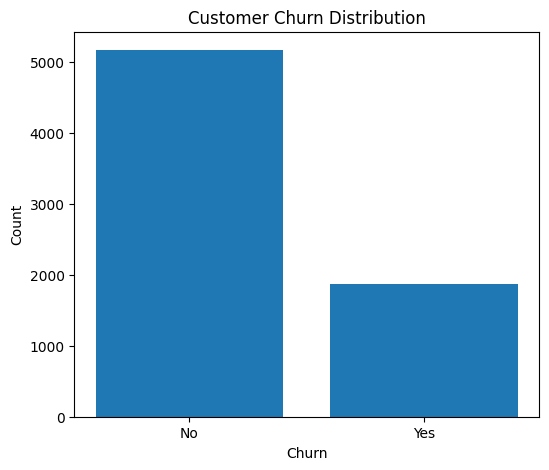

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Customer Churn Distribution")

plt.show()

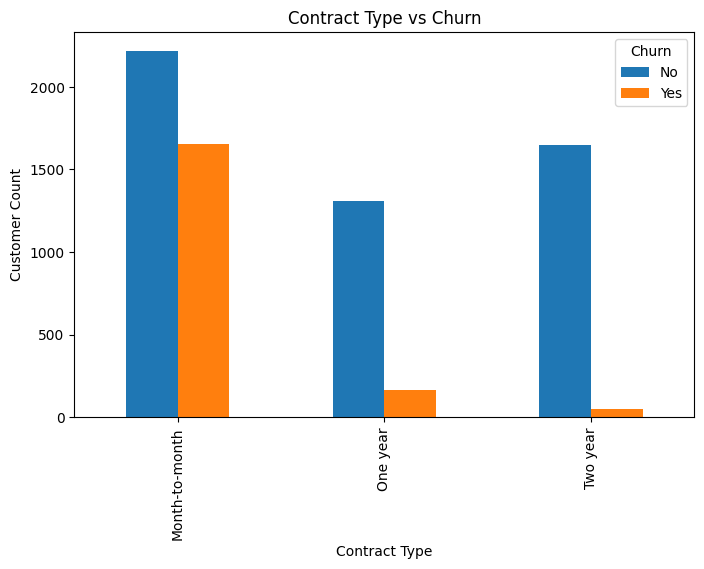

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

contract_churn = (
    df.groupby('Contract')['Churn']
    .value_counts()
    .unstack()
)

contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.title("Contract Type vs Churn")

plt.show()

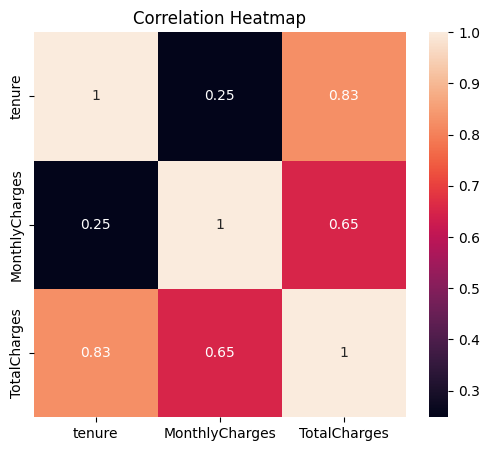

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df_encoded = pd.get_dummies(df)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.67      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.70      1409
weighted avg       0.78      0.80      0.78      1409



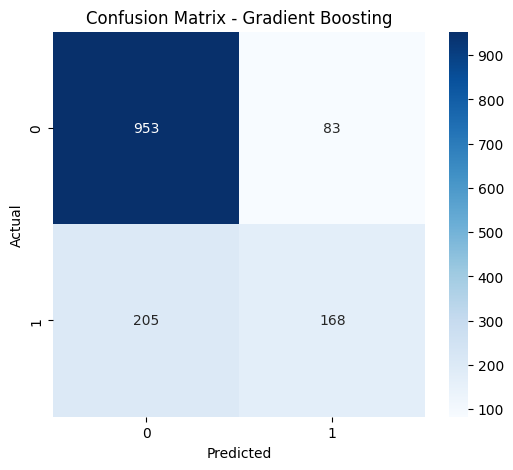

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {name}')

plt.show()

In [20]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.67      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.70      1409
weighted avg       0.78      0.80      0.78      1409



In [23]:
conn = sqlite3.connect('churn_warehouse.db')

query = """
SELECT 
    COUNT(*) AS Total_Customers,
    AVG(MonthlyCharges) AS Avg_Monthly_Charges,
    AVG(TotalCharges) AS Avg_Total_Charges
FROM FACT_CHURN
"""

summary = pd.read_sql(query, conn)

print(summary)

conn.close()

   Total_Customers  Avg_Monthly_Charges  Avg_Total_Charges
0             7043            64.761692        2279.734304


In [24]:
import sqlite3
import pandas as pd

In [25]:
conn = sqlite3.connect('churn_warehouse.db')

In [27]:
conn = sqlite3.connect(
    r"C:\Users\abera\Downloads\churn_warehouse.db"
)

In [28]:
query = """
SELECT *
FROM FACT_CHURN
LIMIT 5
"""

In [29]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('churn_warehouse.db')

query = """
SELECT 
    customerID,
    tenure,
    MonthlyCharges,
    Churn
FROM FACT_CHURN
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)

conn.close()

   customerID  tenure  MonthlyCharges  Churn
0  7590-VHVEG       1           29.85      0
1  5575-GNVDE      34           56.95      0
2  3668-QPYBK       2           53.85      1
3  7795-CFOCW      45           42.30      0
4  9237-HQITU       2           70.70      1
5  9305-CDSKC       8           99.65      1
6  1452-KIOVK      22           89.10      0
7  6713-OKOMC      10           29.75      0
8  7892-POOKP      28          104.80      1
9  6388-TABGU      62           56.15      0


In [32]:
import sqlite3

conn = sqlite3.connect('churn_warehouse.db')

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_CUSTOMER (
    customerID TEXT,
    gender TEXT,
    SeniorCitizen INTEGER,
    Partner TEXT,
    Dependents TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_SERVICE (
    customerID TEXT,
    InternetService TEXT,
    PhoneService TEXT,
    OnlineSecurity TEXT,
    TechSupport TEXT,
    StreamingTV TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS DIM_CONTRACT (
    customerID TEXT,
    Contract TEXT,
    PaymentMethod TEXT,
    PaperlessBilling TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS FACT_CHURN (
    customerID TEXT,
    tenure INTEGER,
    MonthlyCharges REAL,
    TotalCharges REAL,
    Churn INTEGER
)
""")

conn.commit()

print("Data Warehouse Tables Created Successfully")

conn.close()

Data Warehouse Tables Created Successfully


In [33]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [34]:
import sqlite3

conn = sqlite3.connect('churn_warehouse.db')

In [35]:
dim_customer = df[
    [
        'customerID',
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents'
    ]
]

dim_customer.to_sql(
    'DIM_CUSTOMER',
    conn,
    if_exists='append',
    index=False
)

print("DIM_CUSTOMER Loaded Successfully")

DIM_CUSTOMER Loaded Successfully


In [36]:
dim_service = df[
    [
        'customerID',
        'InternetService',
        'PhoneService',
        'OnlineSecurity',
        'TechSupport',
        'StreamingTV'
    ]
]

dim_service.to_sql(
    'DIM_SERVICE',
    conn,
    if_exists='append',
    index=False
)

print("DIM_SERVICE Loaded Successfully")

DIM_SERVICE Loaded Successfully


In [37]:
dim_contract = df[
    [
        'customerID',
        'Contract',
        'PaymentMethod',
        'PaperlessBilling'
    ]
]

dim_contract.to_sql(
    'DIM_CONTRACT',
    conn,
    if_exists='append',
    index=False
)

print("DIM_CONTRACT Loaded Successfully")

DIM_CONTRACT Loaded Successfully


In [38]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

fact_churn = df[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn'
    ]
]

fact_churn.to_sql(
    'FACT_CHURN',
    conn,
    if_exists='append',
    index=False
)

print("FACT_CHURN Loaded Successfully")

FACT_CHURN Loaded Successfully


In [39]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

tables = pd.read_sql(query, conn)

print(tables)

           name
0  DIM_CUSTOMER
1   DIM_SERVICE
2  DIM_CONTRACT
3    FACT_CHURN


In [40]:
query = """
SELECT *
FROM FACT_CHURN
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)

   customerID  tenure  MonthlyCharges  TotalCharges  Churn
0  7590-VHVEG       1           29.85         29.85      0
1  5575-GNVDE      34           56.95       1889.50      0
2  3668-QPYBK       2           53.85        108.15      1
3  7795-CFOCW      45           42.30       1840.75      0
4  9237-HQITU       2           70.70        151.65      1
5  9305-CDSKC       8           99.65        820.50      1
6  1452-KIOVK      22           89.10       1949.40      0
7  6713-OKOMC      10           29.75        301.90      0
8  7892-POOKP      28          104.80       3046.05      1
9  6388-TABGU      62           56.15       3487.95      0
